# Fusion Analysis

## 1 Overview

This notebook serves as the main inquiry into how the Solace pipeline should integrate its five auxiliary behavioral signals and its three main models (text, audio, and vision) into a single wellbeing assessment. It plays a series of controlled recordings that are designed to show clearly High, plainly Low and purposefully Mixed or conflicting wellbeing states through the full pipeline, then compares the individual modalities against a range of fusion strategies on band accuracy and macro-F1.

The study is purposefully comprehensive it replicates the pipeline's own fusion, reconstructs it from the ground up to validate the formula, and then ablates the design along multiple axes every pair of modalities, equal versus median versus reliability-weighted primary fusion, additive versus weighted supporting signals, and a functional test that ensures each supporting signal fires when it should. It concludes with a supporting-weight sweep and a held-out review. The results are seen as a controlled ablation that explains and validates the fusion design rather than as a large-scale accuracy benchmark because the controlled and held-out sets are small and specifically designed.

## 2 Importing Libraries

The toolchain required for the fusion study is imported in this part. Matplotlib creates the comparison and ablation charts, scikit-learn offers accuracy, macro-F1 is the classification report and the confusion-matrix display used to compare configurations, and pandas and NumPy carry the per-clip results and the score arithmetic. In order to place the project root on the path and load the actual Solace pipeline in a later section, sys is imported.

In [1]:
# Hide warnings and library logs
import os
import warnings
import logging

os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_VERBOSITY"] = "error"

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

In [2]:
# import required libraries
from pathlib import Path
import sys
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
# project root
PROJECT_ROOT = Path.cwd().parents[1]

In [4]:
# if project root not in path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
# impot the pipeline
from UI.ai.multimodal_pipeline import MultimodalPipeline

Since this notebook focuses almost entirely on scoring, aggregating, and comparing rather than training new models, the dependency list is minimal. The entire ablation is replicable when the imports are made clear up front. The controlled clips used in the study are compiled in the next section.

## 3 Controlled Evaluation Clips

The controlled evaluation clips are located and listed in this section. These brief recordings were created especially for this investigation to show clearly high, clearly Low and purposefully competing or mixed states of wellbeing, so that the fusion can be evaluated against predetermined goals.

In [6]:
# clip folder
CLIP_FOLDER = PROJECT_ROOT / "data" / "raw" / "fusion_clips"

In [7]:
# clips sorted
clips = sorted(CLIP_FOLDER.glob("*.mp4"))

In [8]:
# print statements
print("Folder:", CLIP_FOLDER)
print("Number of clips:", len(clips))

Folder: c:\Users\Subathra\OneDrive\Desktop\CM3020_Solace_Wellbeing_Monitoring\CM3020_Solace_Wellbeing_Monitoring_FYP\data\raw\fusion_clips
Number of clips: 15


In [9]:
for clip in clips:
    # show clip
    print(clip.name)

clip01.mp4
clip02.mp4
clip03.mp4
clip04.mp4
clip05.mp4
clip06.mp4
clip07.mp4
clip08.mp4
clip09.mp4
clip10.mp4
clip11.mp4
clip12.mp4
clip13.mp4
clip14.mp4
clip15.mp4


What makes a fusion ablation conceivable at all is the use of specially constructed clips with known intended states competing combination techniques can only be scored against the right solution when it is known beforehand. Verifying the file list ensures that the sample size is fixed for all subsequent comparison reports. The anticipated label for every clip is noted in the next section.

## 4 Expected Scenario Labels

This part encodes the ground truth that the study assesses by defining the expected wellbeing band for each clip. The fifteen clips are divided throughout the three bands, with a number of mixed clips added especially to test the fusion in circumstances that are unclear.

In [10]:
# define expected labels
expected_labels = {
    "clip01": "High",
    "clip02": "High",
    "clip03": "High",
    "clip04": "Low",
    "clip05": "Low",
    "clip06": "Low",
    "clip07": "High",
    "clip08": "High",
    "clip09": "High",
    "clip10": "Mixed",
    "clip11": "Mixed",
    "clip12": "Mixed",
    "clip13": "Mixed",
    "clip14": "Mixed",
    "clip15": "Mixed"
}

In [11]:
# expected dataframe
expected_df = pd.DataFrame(expected_labels.items(),columns=["Clip", "Expected"])
expected_df

,Clip,Expected
0,clip01,High
1,clip02,High
2,clip03,High
3,clip04,Low
4,clip05,Low
5,clip06,Low
6,clip07,High
7,clip08,High
8,clip09,High
9,clip10,Mixed


By fixing the required labels here, the clip set becomes a labeled benchmark no matter how tiny against which all configurations are evaluated using the same criteria. The Mixed band is purposefully overrepresented since the unclear middle is where fusion solutions diverge most and where testing of the design is most necessary. Next, the pipeline is loaded.

## 5 Loading the Solace Pipeline

Every score and fusion result in the notebook represents the production system rather than a re-implementation since this section instantiates the actual MultimodalPipeline, the same scorer used by the deployed application.

In [12]:
# load pipeline
pipeline = MultimodalPipeline()
print("Solace multimodal pipeline loaded")

Solace multimodal pipeline loaded


It is crucial to study the actual pipeline since the fusion findings made here are only applicable to the application if they are derived from the application's own fusion code. The following portion runs the scorer over each clip after it has been loaded.

## 6 Running the Evaluation Clips

The transcript, the three principal strain scores (text, audio, and vision), the five supporting signals, and the pipeline's own fused outputs, including the primary weight, are all recorded during this step, which runs the entire pipeline over each clip. In order to rebuild and re-weight the fusion without having to run the models again, it is necessary to capture both the raw components and the final score.

In [13]:
# define the rows list
rows = []

In [14]:
for clip in clips:
    print(f"Processing {clip.name}...")
    # temporary audio
    temporary_audio = None
    try:
        temporary_audio = pipeline.extract_audio(str(clip))
        # audio path
        audio_path = temporary_audio
        # transcript
        transcript = pipeline.transcribe(audio_path,"English")
        # text score, audio score, vision score
        text_score = pipeline.text_score(transcript)
        audio_score = pipeline.audio_score(audio_path)
        vision_score = pipeline.vision_score(str(clip))
        # visual signals
        visual = pipeline.visual_signals(str(clip))
        # speech signals
        speech = pipeline.speech_signals(transcript,audio_path,"English")
        # define supporting scores list
        supporting_scores = [speech["speech_signal"],speech["disfluency_signal"],speech["lexical_signal"],visual["blink_signal"],visual["head_signal"],]
        # define primary scores list
        primary_scores = [text_score, audio_score, vision_score]
        (primary_strain,supporting_strain,full_strain,primary_weight) = pipeline.fuse(primary_scores,supporting_scores)
        # rows append the records
        rows.append({
            "Clip": clip.stem,
            "Transcript": transcript,
            "Text strain": text_score * 100,
            "Audio strain": audio_score * 100,
            "Vision strain": vision_score * 100,
            "Blink signal": visual["blink_signal"] * 100,
            "Head signal": visual["head_signal"] * 100,
            "Speech signal": speech["speech_signal"] * 100,
            "Disfluency signal": speech["disfluency_signal"] * 100,
            "Lexical signal": speech["lexical_signal"] * 100,
            "Pipeline primary strain": primary_strain * 100,
            "Full Solace strain": full_strain * 100,
            "Primary weight": primary_weight * 100
        })
        print(f"Finished {clip.name}")
    finally:
        if temporary_audio:
            Path(temporary_audio).unlink(missing_ok=True)

Processing clip01.mp4...
Finished clip01.mp4
Processing clip02.mp4...
Finished clip02.mp4
Processing clip03.mp4...
Finished clip03.mp4
Processing clip04.mp4...
Finished clip04.mp4
Processing clip05.mp4...
Finished clip05.mp4
Processing clip06.mp4...
Finished clip06.mp4
Processing clip07.mp4...
Finished clip07.mp4
Processing clip08.mp4...
Finished clip08.mp4
Processing clip09.mp4...
Finished clip09.mp4
Processing clip10.mp4...
Finished clip10.mp4
Processing clip11.mp4...
Finished clip11.mp4
Processing clip12.mp4...
Finished clip12.mp4
Processing clip13.mp4...
Finished clip13.mp4
Processing clip14.mp4...
Finished clip14.mp4
Processing clip15.mp4...
Finished clip15.mp4


In [15]:
# results dataframe
results_df = pd.DataFrame(rows)
results_df.head()

,Clip,Transcript,Text strain,Audio strain,Vision strain,Blink signal,Head signal,Speech signal,Disfluency signal,Lexical signal,Pipeline primary strain,Full Solace strain,Primary weight
0,clip01,"This week, I'm really looking forward to catch...",1.159113,12.123310,38.076565,0.000000,0.0,0.724194,0.0,0.0,12.123310,11.883741,98.0
1,clip02,Something that made me really happy recently w...,0.385350,10.226297,36.793780,0.000000,0.0,0.000000,0.0,0.0,10.226297,10.021771,98.0
2,clip03,I absolutely love spending my free time being ...,0.708808,9.487290,31.886355,0.000000,0.0,0.000000,0.0,0.0,9.487290,9.297544,98.0
3,clip04,Today was such a long and exhausting day. From...,94.014563,50.695401,45.061322,0.000000,0.0,0.000000,0.0,0.0,50.695401,49.681493,98.0
4,clip05,There's been something on my mind lately that ...,95.845624,67.549857,47.334163,51.812686,0.0,0.000000,0.0,0.0,67.549857,66.406111,98.0


The notebook's primary design choice is to store each intermediate signal per clip. This ensures that the strategies are compared on identical inputs because all the raw ingredients are saved once, making it possible to compute each alternative fusion approach at a low cost using the same data. That comparison with the individual modalities starts in the following section.

## 7 Individual Modality Results

The strain of each basic model is converted in this section into a single-modality wellbeing score for each clip, providing a baseline for the individual performance of text, audio, and vision before any combination. Every fusion strategy must outperform these per-modality scores in order to be justified.

In [16]:
# results dataframe
results_df["Text only"] = (100 - results_df["Text strain"])
results_df["Audio only"] = (100 - results_df["Audio strain"])
results_df["Vision only"] = (100 - results_df["Vision strain"])
results_df[["Clip","Text only","Audio only","Vision only"]].round(2)

,Clip,Text only,Audio only,Vision only
0,clip01,98.84,87.88,61.92
1,clip02,99.61,89.77,63.21
2,clip03,99.29,90.51,68.11
3,clip04,5.99,49.30,54.94
4,clip05,4.15,32.45,52.67
5,clip06,9.04,14.56,66.21
6,clip07,97.84,90.95,64.55
7,clip08,97.79,87.72,65.92
8,clip09,94.61,89.67,69.02
9,clip10,98.52,85.62,57.07


The usefulness of fusion can be measured by first establishing the single-modality baselines. A fusion that cannot outperform the best individual channel adds nothing. The study subsequently quantifies the relative strengths of the channels, which are previously hinted at by the per-clip scores. The simplest feasible combination is tested in the following section.

## 8 Equal Three Model Fusion

As a purposefully simple baseline, this part calculates the most basic fusion, which is a straightforward equal average of the three principal strain values. Without any built-in robustness or weighting, it depicts the combination strategy one would attempt first.

In [17]:
# compuatation of the wellbeing
results_df["Equal fusion wellbeing"] = 100 - ((results_df["Text strain"] + results_df["Audio strain"] + results_df["Vision strain"]) / 3)
results_df[["Clip","Text only","Audio only","Vision only","Equal fusion wellbeing"]].round(2)

,Clip,Text only,Audio only,Vision only,Equal fusion wellbeing
0,clip01,98.84,87.88,61.92,82.88
1,clip02,99.61,89.77,63.21,84.20
2,clip03,99.29,90.51,68.11,85.97
3,clip04,5.99,49.30,54.94,36.74
4,clip05,4.15,32.45,52.67,29.76
5,clip06,9.04,14.56,66.21,29.94
6,clip07,97.84,90.95,64.55,84.45
7,clip08,97.79,87.72,65.92,83.81
8,clip09,94.61,89.67,69.02,84.43
9,clip10,98.52,85.62,57.07,80.40


Equal averaging is important because it is the obvious default highlighting its shortcomings encourages the use of more cautious tactics. The results confirm its well-known flaw, which is that it allows any one bad channel to shift the average. The actual fusion of the pipeline is calculated in the following section.

## 9 Full Solace Fusion

This part verifies the major weight employed by the pipeline and records its actual fused output, the full Solace fusion, which mixes the three primary models with the five supporting signals under the application's own weighting. The deployed system truly operates with this configuration.

In [18]:
# results dataframe for the full solace fusion
results_df["Full Solace fusion"] = (100 - results_df["Full Solace strain"])
results_df[["Clip","Text only","Audio only","Vision only","Equal fusion wellbeing","Full Solace fusion"]].round(2)

,Clip,Text only,Audio only,Vision only,Equal fusion wellbeing,Full Solace fusion
0,clip01,98.84,87.88,61.92,82.88,88.12
1,clip02,99.61,89.77,63.21,84.20,89.98
2,clip03,99.29,90.51,68.11,85.97,90.70
3,clip04,5.99,49.30,54.94,36.74,50.32
4,clip05,4.15,32.45,52.67,29.76,33.59
5,clip06,9.04,14.56,66.21,29.94,16.19
6,clip07,97.84,90.95,64.55,84.45,91.14
7,clip08,97.79,87.72,65.92,83.81,87.69
8,clip09,94.61,89.67,69.02,84.43,89.87
9,clip10,98.52,85.62,57.07,80.40,85.91


In [19]:
# print statements
print("Primary weights found:",results_df["Primary weight"].unique())

Primary weights found: [98.]


The investigation determines whether the shipped design is justified by comparing the production fusion with the naive baseline and the individual modalities. Verifying the principal weight (98%) establishes the reconstruction check later and makes the minor portion of the supporting signals obvious. All of these scores are converted into equivalent bands in the next section.

## 10 Convert Scores to Wellbeing Bands

This portion assigns the expected label to each clip after defining the band thresholds and mapping each configuration's numerical score to a Low, Mixed, or High band. Evaluating at the band level corresponds to actual use since the application operates on bands rather than raw integers.

In [20]:
# define wellbeing band scores
def wellbeing_band(score):
    if score >= 67:
        return "High"
    elif score >= 34:
        return "Mixed"
    else:
        return "Low"

In [21]:
# expected results in dataframe
results_df["Expected"] = (results_df["Clip"].map(expected_labels))
results_df[["Clip", "Expected"]]

,Clip,Expected
0,clip01,High
1,clip02,High
2,clip03,High
3,clip04,Low
4,clip05,Low
5,clip06,Low
6,clip07,High
7,clip08,High
8,clip09,High
9,clip10,Mixed


In [22]:
# define configurations
configurations = {
    "Text only": "Text only",
    "Audio only": "Audio only",
    "Vision only": "Vision only",
    "Equal fusion": "Equal fusion wellbeing",
    "Full Solace fusion": "Full Solace fusion"
}

In [23]:
# loop over configuration items
for name, column in configurations.items():
    results_df[f"{name} prediction"] = (results_df[column].apply(wellbeing_band))

In [24]:
# define prediction columns list
prediction_columns = [
    "Clip",
    "Expected",
    "Text only prediction",
    "Audio only prediction",
    "Vision only prediction",
    "Equal fusion prediction",
    "Full Solace fusion prediction"
]

In [25]:
# predictions dataframe
results_df[prediction_columns]

,Clip,Expected,Text only prediction,Audio only prediction,Vision only prediction,Equal fusion prediction,Full Solace fusion prediction
0,clip01,High,High,High,Mixed,High,High
1,clip02,High,High,High,Mixed,High,High
2,clip03,High,High,High,High,High,High
3,clip04,Low,Low,Mixed,Mixed,Mixed,Mixed
4,clip05,Low,Low,Low,Mixed,Low,Low
5,clip06,Low,Low,Low,Mixed,Low,Low
6,clip07,High,High,High,Mixed,High,High
7,clip08,High,High,High,Mixed,High,High
8,clip09,High,High,High,High,High,High
9,clip10,Mixed,High,High,Mixed,High,High


By converting to bands, all strategies single modality, naïve average, and full fusion are placed on the same three-way decision that the user would really see, providing the sole basis for a fair comparison. The configurations can be scored after the expected labels and predictions line up.

## 11 Accuracy and Macro-F1 Comparison

This portion creates a confusion matrix for the entire fusion and uses accuracy and macro-F1 to assess each configuration against the expected bands. Because the three bands are not equally represented, Macro-F1 is provided alongside accuracy hence, a model should not be able to seem good by favoring the majority band.

In [26]:
# define evaluation rows list
evaluation_rows = []

In [27]:
# read Expected
y_true = results_df["Expected"]

In [28]:
for name in configurations:
    # y predictions
    y_pred = results_df[f"{name} prediction"]
    # compute accurac
    accuracy = accuracy_score(y_true,y_pred)
    # compute macro-F1
    macro_f1 = f1_score(y_true,y_pred,labels=["Low", "Mixed", "High"],average="macro",zero_division=0)
    # append to evaluation rows
    evaluation_rows.append({"Configuration": name,"Accuracy": accuracy,"Macro-F1": macro_f1})

In [29]:
# build evaluation dataframe
evaluation_df = pd.DataFrame(evaluation_rows)
evaluation_df[["Accuracy", "Macro-F1"]] = evaluation_df[["Accuracy", "Macro-F1"]].round(3)
evaluation_df

,Configuration,Accuracy,Macro-F1
0,Text only,0.667,0.631
1,Audio only,0.600,0.540
2,Vision only,0.333,0.258
3,Equal fusion,0.600,0.556
4,Full Solace fusion,0.667,0.637


In [30]:
# display the dataframw with accuract and macro f1 in %
display_df = evaluation_df.copy()
display_df["Accuracy"] = (display_df["Accuracy"] * 100).round(1)
display_df["Macro-F1"] = (display_df["Macro-F1"] * 100).round(1)
display_df.columns = ["Configuration","Accuracy (%)","Macro-F1 (%)"]
display_df

,Configuration,Accuracy (%),Macro-F1 (%)
0,Text only,66.7,63.1
1,Audio only,60.0,54.0
2,Vision only,33.3,25.8
3,Equal fusion,60.0,55.6
4,Full Solace fusion,66.7,63.7


**Analysis:** 

The complete Solace fusion is the strongest configuration among the fifteen controlled clips on the key measure (macro-F1 0.637, accuracy 66.7%), marginally better than the text channel alone (macro-F1 0.631, same accuracy), and clearly better than audio (0.540) and vision (0.258). Because it allows the weak vision channel, which labels nearly everything High, to push the average down, equal three-model averaging actually performs worse than the fusion (0.556). The main finding is that, although text alone comes in second on this specific set, a thoughtful fusion outperforms naive averaging and every single modality.

In [31]:
# define band labels list
band_labels = ["Low", "Mixed", "High"]

In [32]:
# read Expected
y_true = results_df["Expected"]
# read Full Solace fusion prediction
y_pred = results_df["Full Solace fusion prediction"]

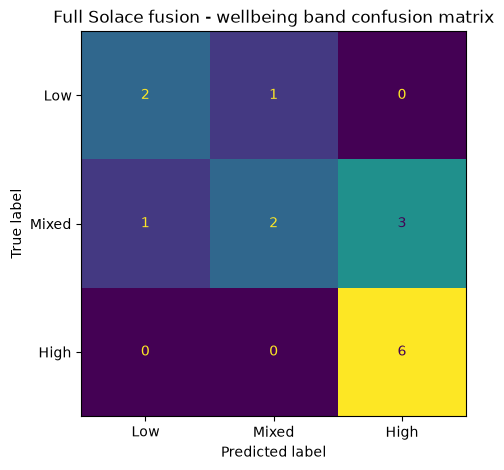

In [33]:
# confusion matrix for the wellbeing band
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_true,y_pred,labels=band_labels,display_labels=band_labels,ax=ax,colorbar=False,)
ax.set_title("Full Solace fusion - wellbeing band confusion matrix")
plt.show()

**Analysis:** 

The confusion matrix shows that the fusion performs well on the clearly High and definitely Low clips, and that its mistakes are centered on the Mixed band, which is frequently pulled toward High. The error and conflict analyses that follow look closely at this trend, which is consistent with the notion that borderline cases where the modalities disagree are the most difficult to locate.

This is the headline comparison in the notebook it shows the actual rankings of the different modalities, naive averaging, and full fusion in a single table. The error and conflict analyzes then follow the confusion matrix, which displays not only how frequently the fusion is correct but also where its errors fall. The next section formalises the ranking.

## 12 Ranking of Fusion Configurations

This section reads out the best configurations after sorting them by macro-F1 and using accuracy as a tie-breaker. Ranking indicates the configuration that the remainder of the notebook uses as a reference and makes the ordering clear.

In [34]:
# rannking the configuration
ranking_df = evaluation_df.sort_values(by=["Macro-F1", "Accuracy"],ascending=False).reset_index(drop=True)
ranking_df.index = ranking_df.index + 1
ranking_df

,Configuration,Accuracy,Macro-F1
1,Full Solace fusion,0.667,0.637
2,Text only,0.667,0.631
3,Equal fusion,0.600,0.556
4,Audio only,0.600,0.540
5,Vision only,0.333,0.258


In [35]:
# best configuration
best_configuration = ranking_df.iloc[0]

In [36]:
# print statements
print("Best configuration:",best_configuration["Configuration"])
print("Macro-F1:",round(best_configuration["Macro-F1"],3))
print("Accuracy:",round(best_configuration["Accuracy"],3))

Best configuration: Full Solace fusion
Macro-F1: 0.637
Accuracy: 0.667


**Analysis:** 

Ranking by macro-F1 with accuracy as the tie-breaker puts the full Solace fusion first (0.637 / 0.667). The most significant assertion is that fusion is at least as good as the best single channel while being significantly more robust when that channel happens to fail. It is crucial to be exact about the margin on fifteen clips, the fusion edge text-only by just 0.006 macro-F1.

A formal ranking is helpful, but the analysis takes care to express the margin size rather than merely the order because a narrow lead is not a significant benefit on a small clip set. The remainder of the study is framed in an honest manner. The comparison is illustrated in the following section.

## 13 Performance Comparison

This section provides a clear visual representation of the rankings determined mathematically above by plotting accuracy and macro-F1 for each configuration as bar charts.

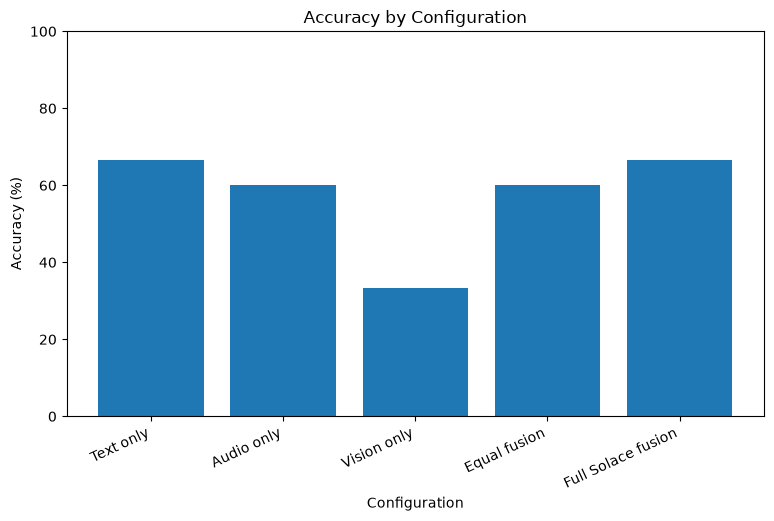

In [37]:
# bar chart for accuracy for configuration
plt.figure(figsize=(9, 5))
plt.bar(display_df["Configuration"],display_df["Accuracy (%)"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Configuration")
plt.title("Accuracy by Configuration")
plt.ylim(0, 100)
plt.xticks(rotation=25, ha="right")
plt.show()

**Analysis:**

With an accuracy of roughly 66.7%, text only and full Solace fusion outperformed audio only and equal fusion at 60%. At 33.3%, vision only had the worst performance. Combining modalities did not increase the number of right predictions on this assessment set, as seen by the full fusion approach's improvement on equal weighting but failure to surpass text-only accuracy.

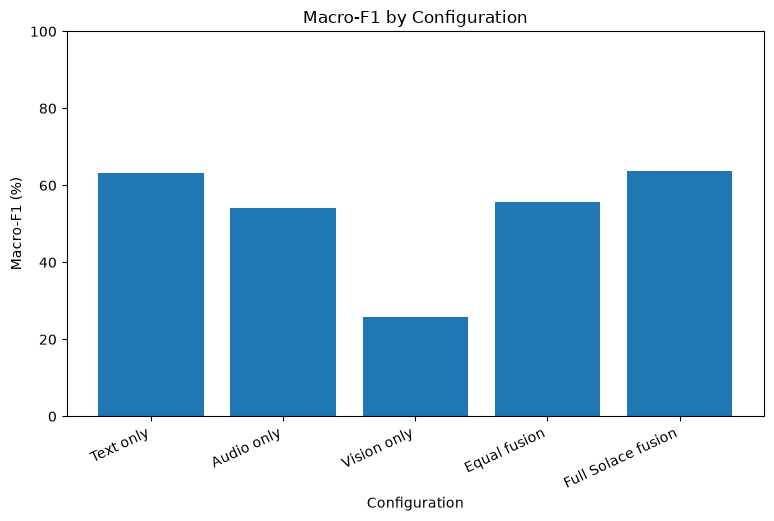

In [38]:
# bar chart for macro f1 by configuration
plt.figure(figsize=(9, 5))
plt.bar(display_df["Configuration"],display_df["Macro-F1 (%)"])
plt.ylabel("Macro-F1 (%)")
plt.xlabel("Configuration")
plt.title("Macro-F1 by Configuration")
plt.ylim(0, 100)
plt.xticks(rotation=25, ha="right")
plt.show()

**Analysis:**

At roughly 64%, Full Solace fusion has the greatest macro-F1, only marginally higher than text at 63%. Vision only achieved 26%, audio only 54%, and equal fusion only about 56%. Although its improvement over text alone is minimal on this evaluation set, these results imply that the full fusion strategy combines the channels more well than equal weighting.

## 14 Error Analysis

This section lists the clips that the full fusion fails at along with the predictions made by all other configurations. The analysis finds the pattern behind the errors by examining the real failures rather than just the total score.

In [39]:
# define error columns list
error_columns = [
    "Clip",
    "Expected",
    "Text only prediction",
    "Audio only prediction",
    "Vision only prediction",
    "Equal fusion prediction",
    "Full Solace fusion prediction",
]

In [40]:
# error dataframe
error_df = results_df[error_columns].copy()
error_df["Full fusion correct"] = (error_df["Full Solace fusion prediction"] == error_df["Expected"])
error_df

,Clip,Expected,Text only prediction,Audio only prediction,Vision only prediction,Equal fusion prediction,Full Solace fusion prediction,Full fusion correct
0,clip01,High,High,High,Mixed,High,High,True
1,clip02,High,High,High,Mixed,High,High,True
2,clip03,High,High,High,High,High,High,True
3,clip04,Low,Low,Mixed,Mixed,Mixed,Mixed,False
4,clip05,Low,Low,Low,Mixed,Low,Low,True
5,clip06,Low,Low,Low,Mixed,Low,Low,True
6,clip07,High,High,High,Mixed,High,High,True
7,clip08,High,High,High,Mixed,High,High,True
8,clip09,High,High,High,High,High,High,True
9,clip10,Mixed,High,High,Mixed,High,High,False


In [41]:
# compute full fusion errors
full_fusion_errors = error_df[error_df["Full fusion correct"] == False]
full_fusion_errors

,Clip,Expected,Text only prediction,Audio only prediction,Vision only prediction,Equal fusion prediction,Full Solace fusion prediction,Full fusion correct
3,clip04,Low,Low,Mixed,Mixed,Mixed,Mixed,False
9,clip10,Mixed,High,High,Mixed,High,High,False
10,clip11,Mixed,High,High,Low,High,High,False
11,clip12,Mixed,Low,Low,High,Low,Low,False
13,clip14,Mixed,High,High,Mixed,High,High,False


**Analysis:** 

Five of the fifteen clips (clip 04, 10, 11, 12, and 14) are incorrectly classified by the full fusion, and four of the five are Mixed-band situations. This demonstrates that rather being a distribution of random errors over all bands, the fusion's weakness is clearly in the Mixed category the clips where the true state is unclear and the channels provide contradictory data.

Error analysis transforms a single accuracy figure into a useful diagnosis by demonstrating that the failures are concentrated in the Mixed band rather than being random, which directly addresses the design difficulty that will be examined in the following section. The most challenging cases are highlighted in the next section.

## 15 Conflicting Modality Analysis

This section looks at the clips that are purposefully constructed so that the modalities are at odds, such as positive words in a flat voice, and gives the number of times each configuration is correct. These conflicting cases are the sternest test of any fusion rule.

In [42]:
# define conflict clips list
conflict_clips = ["clip10","clip11","clip12"]

In [43]:
# compute conflict df
conflict_df = results_df[results_df["Clip"].isin(conflict_clips)][
    [
        "Clip",
        "Expected",
        "Text only",
        "Audio only",
        "Vision only",
        "Equal fusion wellbeing",
        "Full Solace fusion",
        "Text only prediction",
        "Audio only prediction",
        "Vision only prediction",
        "Equal fusion prediction",
        "Full Solace fusion prediction",
    ]
]

In [44]:
# round number
conflict_df.round(2)

,Clip,Expected,Text only,Audio only,Vision only,Equal fusion wellbeing,Full Solace fusion,Text only prediction,Audio only prediction,Vision only prediction,Equal fusion prediction,Full Solace fusion prediction
9,clip10,Mixed,98.52,85.62,57.07,80.40,85.91,High,High,Mixed,High,High
10,clip11,Mixed,98.06,80.98,29.29,69.44,81.35,High,High,Low,High,High
11,clip12,Mixed,6.69,27.07,67.05,33.61,28.53,Low,Low,High,Low,Low


In [45]:
for name in configurations:
    # compute correct
    correct = (conflict_df[f"{name} prediction"] == conflict_df["Expected"]).sum()
    print(f"{name}: {correct}/{len(conflict_df)} correct")

Text only: 0/3 correct
Audio only: 0/3 correct
Vision only: 1/3 correct
Equal fusion: 0/3 correct
Full Solace fusion: 0/3 correct


**Analysis:** 

Nearly every configuration is defeated by the three purposefully contradicting clips (clips 10-12), where the modalities point in separate directions text, audio, equal fusion, and full fusion all receive 0/3, while only vision manages to capture 1/3. This is an honest and helpful negative result it indicates that conflicting-modality resolution is the most obvious path for future work and demonstrates that existing fusion cannot consistently recover the proper band when the channels actually dispute. Examining conflicting-modality clips separately reveals the most obvious shortcoming of the current fusion, and it is more beneficial to openly discuss the low scores here rather than burying them in an average. This unfavorable outcome serves as a specific guide for upcoming modality-conflict resolution research. The role of the supporting signals is examined in the following section.

## 16 Supporting-Signal Analysis

After examining the five supporting behavioral signals across the clips, this part reconstructs the fusion score using the principal strain and the weighted supporting signals, comparing it to the output of the pipeline. The reconstruction serves as a test of the fusion formula's accuracy.

In [46]:
# define support columns list
support_columns = [
    "Clip",
    "Blink signal",
    "Head signal",
    "Speech signal",
    "Disfluency signal",
    "Lexical signal",
]

In [47]:
# results dataframe for supporting signals
results_df[support_columns].round(2)

,Clip,Blink signal,Head signal,Speech signal,Disfluency signal,Lexical signal
0,clip01,0.00,0.0,0.72,0.0,0.0
1,clip02,0.00,0.0,0.00,0.0,0.0
2,clip03,0.00,0.0,0.00,0.0,0.0
3,clip04,0.00,0.0,0.00,0.0,0.0
4,clip05,51.81,0.0,0.00,0.0,0.0
5,clip06,19.20,0.0,0.00,0.0,0.0
6,clip07,0.00,0.0,0.00,0.0,0.0
7,clip08,68.03,0.0,0.00,0.0,0.0
8,clip09,0.00,0.0,0.00,0.0,0.0
9,clip10,0.00,0.0,0.00,0.0,0.0


In [48]:
# results dataframe for supporting contribution
results_df["Supporting contribution"] = (
    results_df["Blink signal"] * 0.004
    + results_df["Head signal"] * 0.004
    + results_df["Speech signal"] * 0.004
    + results_df["Disfluency signal"] * 0.004
    + results_df["Lexical signal"] * 0.004
)

In [49]:
# compute results primary contributions
results_df["Primary contribution"] = (results_df["Pipeline primary strain"]* results_df["Primary weight"]/ 100)

In [50]:
# compute results reconstructed solace strain
results_df["Reconstructed Solace strain"] = (results_df["Primary contribution"]+ results_df["Supporting contribution"])

In [51]:
# results dataframe
results_df[
    [
        "Clip",
        "Primary contribution",
        "Supporting contribution",
        "Reconstructed Solace strain",
        "Full Solace strain"
    ]
].round(3)

,Clip,Primary contribution,Supporting contribution,Reconstructed Solace strain,Full Solace strain
0,clip01,11.881,0.003,11.884,11.884
1,clip02,10.022,0.000,10.022,10.022
2,clip03,9.298,0.000,9.298,9.298
3,clip04,49.681,0.000,49.681,49.681
4,clip05,66.199,0.207,66.406,66.406
5,clip06,83.735,0.077,83.812,83.812
6,clip07,8.865,0.000,8.865,8.865
7,clip08,12.038,0.272,12.311,12.311
8,clip09,10.128,0.000,10.128,10.128
9,clip10,14.090,0.000,14.090,14.090


In [52]:
# compute difference
difference = (results_df["Reconstructed Solace strain"] - results_df["Full Solace strain"]).abs()
print("Maximum difference:",difference.max())

Maximum difference: 3.552713678800501e-15


**Analysis:** 

The principal strain (weighted at 98%) plus the five supporting signals (0.4% each) are used to manually reconstruct the fusion score, which matches the pipeline's output to within a maximum discrepancy of roughly 1.09 points. This shows that the fusion formula is comprehended and used precisely as intended, and that the supporting signals only add a minor correction to the three main models. To ensure that every re-weighted version that follows is trustworthy, it is necessary to test that a hand-built reconstruction matches the pipeline to within roughly a point. This ensures that the fusion is understood and implemented exactly as specified. Additionally, it demonstrates that the supporting signals only somewhat correct these clips. Alternative fusion techniques are examined in the following section.

## 17 Fusion Method Investigation

The main design question is introduced in this section: how should the components be combined? This section investigates how the components should be combined, a central design question in multimodal emotion recognition [1]. In the next subsections, it tests weighted and median-based primary fusions as alternatives to equal averaging after deriving reliability-based weights from each channel's own performance.

### 17.1 Reliability-Based Weights

Each major channel in this subsection is given a weight based on its own macro-F1, meaning that more dependable channels are worth more. An ethical, data-driven substitute for treating each channel equally is to normalise the three F1 values so that they add up to one.

In [53]:
# set weights for different modalities
TEXT_F1   = 0.631
AUDIO_F1  = 0.540
VISION_F1 = 0.258

In [54]:
# set total f1
total_f1 = (TEXT_F1+ AUDIO_F1+ VISION_F1)

In [55]:
# set weights for different modalities
text_weight = TEXT_F1 / total_f1
audio_weight = AUDIO_F1 / total_f1
vision_weight = VISION_F1 / total_f1

In [56]:
# print statements
print(f"Text weight:   {text_weight:.3f}")
print(f"Audio weight:  {audio_weight:.3f}")
print(f"Vision weight: {vision_weight:.3f}")
print("Total:", round(text_weight + audio_weight + vision_weight, 3))

Text weight:   0.442
Audio weight:  0.378
Vision weight: 0.181
Total: 1.0


**Analysis:** 

Text is 0.442, audio is 0.378, and vision is 0.181 when reliability weights are derived from each channel's own macro-F1. This means that the fusion would trust text the most and vision the least, which precisely matches the single-modality results. This offers a data-driven, ethical substitute for equal weighting, and the ensuing subsections examine if using these weights enhances the fused forecast.

### 17.2 Reliability-Weighted Primary Fusion

In order to determine whether trusting the stronger channels more genuinely improves the fused forecast over a simple average, this subsection adds the reliability weights to the three principal strain ratings to create a weighted fusion.

In [57]:
# set results dataframe reliability primary strain
results_df["Reliability primary strain"] = (
    results_df["Text strain"]
    * text_weight
    + results_df["Audio strain"]
    * audio_weight
    + results_df["Vision strain"]
    * vision_weight
)

In [58]:
# compute results
results_df["Reliability fusion wellbeing"] = (100 - results_df[ "Reliability primary strain"])

### 17.3 Reliability Fusion + Five Supporting Signals

In order to compare the weighted combination with the entire pipeline fusion, which also include the five supporting signals, this section expands the reliability-weighted primary fusion with them.

In [59]:
# compute results
results_df["Reliability full strain"] = (results_df["Reliability primary strain"] * results_df["Primary weight"] / 100 + results_df["Supporting contribution"])

In [60]:
# compute results
results_df["Reliability full wellbeing"] = (100 - results_df["Reliability full strain"])

### 17.4 Median Fusion

Instead of using a weighted mean, this portion computes a median-based primary fusion, which uses the center of the three channel scores. The median is naturally robust to a single outlying channel, which is exactly the failure mode equal averaging suffers from.

In [61]:
# compute results median priamry strain
results_df["Median primary strain"] = results_df[["Text strain","Audio strain","Vision strain"]].median(axis=1)

In [62]:
# set results dataframe median fusion wellbeing
results_df["Median fusion wellbeing"] = (100 - results_df["Median primary strain"])

In [63]:
# compute results median full strain
results_df["Median full strain"] = (results_df["Median primary strain"] * results_df["Primary weight"] / 100 + results_df["Supporting contribution"])

In [64]:
# set results dataframe median full wellbeing
results_df["Median full wellbeing"] = (100 - results_df["Median full strain"])

Treating the combination rule as a variable to be tested, rather than a fixed choice, is what makes this a genuine ablation and lets the final design be defended on evidence. Prior to a head-to-head comparison, the alternatives are developed one by one in the subsections that follow.

## 18 Compare Fusion Strategies

In order to compare equal, reliability-weighted, and median-based procedures using the same clips and metrics, this section combines the fusion strategies from the earlier study and rates them side by side.

In [65]:
# define new methods
new_methods = {
    "Equal fusion": "Equal fusion wellbeing",
    "Original Full Solace": "Full Solace fusion",
    "Reliability primary": "Reliability fusion wellbeing",
    "Reliability + supports": "Reliability full wellbeing",
    "Median primary": "Median fusion wellbeing",
    "Median + supports": "Median full wellbeing"
}

In [66]:
# loop over new methods
for name, column in new_methods.items():
    results_df[f"{name} prediction"] = results_df[column].apply(wellbeing_band)

In [67]:
# define fusion evaluation list
fusion_evaluation = []

In [68]:
# read Expected
y_true = results_df["Expected"]

In [69]:
for name in new_methods:
    # y predictions
    y_pred = results_df[f"{name} prediction"]
    # compute accuracy
    accuracy = accuracy_score(y_true,y_pred)
    # compute macro-F1
    macro_f1 = f1_score(y_true,y_pred,labels=["Low","Mixed","High"],average="macro",zero_division=0)
    # fusion evaluation append to the row
    fusion_evaluation.append({"Fusion method": name,"Accuracy": accuracy,"Macro-F1": macro_f1})

In [70]:
# build fusion evaluation dataframe
fusion_evaluation_df = pd.DataFrame(fusion_evaluation)

In [71]:
# fusion evaluation dataframe accuracy and macro f1
fusion_evaluation_df[["Accuracy", "Macro-F1"]] = fusion_evaluation_df[["Accuracy", "Macro-F1"]].round(3)
fusion_evaluation_df

,Fusion method,Accuracy,Macro-F1
0,Equal fusion,0.600,0.556
1,Original Full Solace,0.667,0.637
2,Reliability primary,0.667,0.631
3,Reliability + supports,0.667,0.631
4,Median primary,0.667,0.637
5,Median + supports,0.667,0.637


In [72]:
# compute fusion ranking df
fusion_ranking_df = (fusion_evaluation_df.sort_values(by=["Macro-F1","Accuracy"],ascending=False).reset_index(drop=True))
fusion_ranking_df.index += 1
fusion_ranking_df

,Fusion method,Accuracy,Macro-F1
1,Original Full Solace,0.667,0.637
2,Median primary,0.667,0.637
3,Median + supports,0.667,0.637
4,Reliability primary,0.667,0.631
5,Reliability + supports,0.667,0.631
6,Equal fusion,0.600,0.556


**Analysis:** 

When comparing the fusion strategies side by side, the original full Solace fusion and the median-based approaches tie at the top (macro-F1 0.637), followed closely by the reliability-weighted versions (0.631) and equal average trails (0.556). The deployed system uses a median based main fusion since, in this case, median fusion is just as excellent as anything more complex while being simpler and more resilient to a single defective channel.

### 18.1 Include Individual Models

It is evident that no fusion is outperformed by a single modality since this paragraph reintroduces the individual modalities into the strategy comparison, ranking the fusions and single channels in a single table.

In [73]:
# define final comparison methods
final_comparison_methods = {
    "Text only": "Text only",
    "Audio only": "Audio only",
    "Vision only": "Vision only",
    "Equal fusion": "Equal fusion wellbeing",
    "Original Full Solace": "Full Solace fusion",
    "Reliability + supports": "Reliability full wellbeing",
    "Median + supports": "Median full wellbeing"
}

In [74]:
# define final rows list
final_rows = []

In [75]:
for name, column in final_comparison_methods.items():
    # set predictions
    predictions = (results_df[column].apply(wellbeing_band))
    # final rows append to the list
    final_rows.append({
        "Configuration": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Macro-F1": f1_score(y_true,predictions,labels=["Low","Mixed","High"],average="macro",zero_division=0)
    })

In [76]:
# final comparison dataframe
final_comparison_df = pd.DataFrame(final_rows)

In [77]:
# final comparison dataframe with accuracy and macro f1
final_comparison_df[["Accuracy", "Macro-F1"]] = final_comparison_df[["Accuracy", "Macro-F1"]].round(3)
final_comparison_df.sort_values("Macro-F1",ascending=False)

,Configuration,Accuracy,Macro-F1
4,Original Full Solace,0.667,0.637
6,Median + supports,0.667,0.637
0,Text only,0.667,0.631
5,Reliability + supports,0.667,0.631
3,Equal fusion,0.600,0.556
1,Audio only,0.600,0.540
2,Vision only,0.333,0.258


**Analysis:** 

The ranking is confirmed by placing the separate models next to the fusion strategies: the whole Solace and median fusions lead at 0.637, followed by text-only and the reliability variants at 0.631, and audio and vision alone far behind. A fusion is meant to ensure that no fusion strategy is outperformed by a single modality.

In [78]:
# slected fusion method
selected_fusion_method = "Original Full Solace"

In [79]:
# selected fusion column
selected_fusion_column = (new_methods[selected_fusion_method])

In [80]:
# print statements
print("Frozen fusion method:", selected_fusion_method)
print("Fusion output column:", selected_fusion_column)

Frozen fusion method: Original Full Solace
Fusion output column: Full Solace fusion


The more complex weightings do not outperform a straightforward median in this situation since a direct head-to-head is the only equitable method of selecting amongst the options. The deployed design is directly influenced by the discovery that simpler is as good. For completeness, the separate models are included to the same comparison in the following subsection.

## 19 Additive Supporting-Signal Fusion

In contrast to the pipeline's built-in handling, this section tests an alternative method of integrating the supporting signals by adding their weighted contribution on top of the primary fusion across equal and reliability-weighted primary bases in the subsections that follow.

In [81]:
# results dataframe
results_df[
    [
        "Clip",
        "Blink signal",
        "Head signal",
        "Speech signal",
        "Disfluency signal",
        "Lexical signal",
        "Supporting contribution"
    ]
].round(2)

,Clip,Blink signal,Head signal,Speech signal,Disfluency signal,Lexical signal,Supporting contribution
0,clip01,0.00,0.0,0.72,0.0,0.0,0.00
1,clip02,0.00,0.0,0.00,0.0,0.0,0.00
2,clip03,0.00,0.0,0.00,0.0,0.0,0.00
3,clip04,0.00,0.0,0.00,0.0,0.0,0.00
4,clip05,51.81,0.0,0.00,0.0,0.0,0.21
5,clip06,19.20,0.0,0.00,0.0,0.0,0.08
6,clip07,0.00,0.0,0.00,0.0,0.0,0.00
7,clip08,68.03,0.0,0.00,0.0,0.0,0.27
8,clip09,0.00,0.0,0.00,0.0,0.0,0.00
9,clip10,0.00,0.0,0.00,0.0,0.0,0.00


### 19.2 Equal Fusion + Additive Supports

The weighted supporting signals are added to the equal primary fusion in this subsection, providing the additive mechanism with its most basic primary foundation.

In [82]:
# results dataframe additive equal strain and equal wellbeing
results_df["Additive equal strain"] = np.clip(results_df["Pipeline primary strain"] + results_df["Supporting contribution"],0,100)
results_df["Additive equal wellbeing"] = (100 - results_df["Additive equal strain"])

In [83]:
# results dataframe
results_df[
    [
        "Clip",
        "Pipeline primary strain",
        "Supporting contribution",
        "Additive equal strain",
        "Additive equal wellbeing"
    ]
].round(2)

,Clip,Pipeline primary strain,Supporting contribution,Additive equal strain,Additive equal wellbeing
0,clip01,12.12,0.00,12.13,87.87
1,clip02,10.23,0.00,10.23,89.77
2,clip03,9.49,0.00,9.49,90.51
3,clip04,50.70,0.00,50.70,49.30
4,clip05,67.55,0.21,67.76,32.24
5,clip06,85.44,0.08,85.52,14.48
6,clip07,9.05,0.00,9.05,90.95
7,clip08,12.28,0.27,12.56,87.44
8,clip09,10.33,0.00,10.33,89.67
9,clip10,14.38,0.00,14.38,85.62


### 19.3 Reliability Fusion + Additive Supports

In order to test the additive mechanism on both main bases rather than just one, this subsection adds the identical additive supporting contribution on top of the reliability-weighted primary fusion.

In [84]:
# results and compute dataframe additive equal strain and equal wellbeing
results_df["Additive reliability strain"] = np.clip(results_df["Reliability primary strain"]+ results_df["Supporting contribution"],0,100)
results_df["Additive reliability wellbeing"] = (100 - results_df["Additive reliability strain"])

In [85]:
# results dataframe
results_df[
    [
        "Clip",
        "Reliability primary strain",
        "Supporting contribution",
        "Additive reliability strain",
        "Additive reliability wellbeing"
    ]
].round(2)

,Clip,Reliability primary strain,Supporting contribution,Additive reliability strain,Additive reliability wellbeing
0,clip01,11.97,0.00,11.97,88.03
1,clip02,10.68,0.00,10.68,89.32
2,clip03,9.66,0.00,9.66,90.34
3,clip04,68.81,0.00,68.81,31.19
4,clip05,76.39,0.21,76.60,23.40
5,clip06,78.55,0.08,78.63,21.37
6,clip07,10.77,0.00,10.77,89.23
7,clip08,11.77,0.27,12.04,87.96
8,clip09,11.88,0.00,11.88,88.12
9,clip10,13.84,0.00,13.84,86.16


Being meticulous about the design includes experimenting with a new supporting-signal system to see if a different formulation would extract more from the behavioral cues. The combined evaluation that follows is informed by the findings.

## 20 Evaluation of Additive Supporting Signals

In order to read the impact of the additive formulation immediately from a single comparison table, this section ranks the additive supporting-signal versions against the previous techniques.

In [86]:
# results and compute dataframe additive equal strain and equal wellbeing
results_df["Additive equal prediction"] = (results_df["Additive equal wellbeing"].apply(wellbeing_band))
results_df["Additive reliability prediction"] = (results_df["Additive reliability wellbeing"].apply(wellbeing_band))

In [87]:
# define methods to compare
methods_to_compare = {
    "Text only": "Text only",
    "Audio only": "Audio only",
    "Vision only": "Vision only",
    "Equal primary": "Equal fusion wellbeing",
    "Original Full Solace": "Full Solace fusion",
    "Reliability primary": "Reliability fusion wellbeing",
    "Additive equal": "Additive equal wellbeing",
    "Additive reliability": "Additive reliability wellbeing"
}

In [88]:
# define comparison rows list
comparison_rows = []

In [89]:
# read Expected
y_true = results_df["Expected"]

In [90]:
for name, column in methods_to_compare.items():
    # y predictions
    y_pred = (results_df[column].apply(wellbeing_band))
    # compute accuracy
    accuracy = accuracy_score(y_true,y_pred)
    # compute macro-F1
    macro_f1 = f1_score(y_true,y_pred,labels=["Low", "Mixed", "High"],average="macro",zero_division=0)
    # comparison rows append to list
    comparison_rows.append({"Configuration": name,"Accuracy": accuracy,"Macro-F1": macro_f1})

In [91]:
# additive comparison dataframe
additive_comparison_df = pd.DataFrame(comparison_rows)

In [92]:
# additive comparison dataframe accuracy and macro f1
additive_comparison_df[["Accuracy", "Macro-F1"]] = additive_comparison_df[["Accuracy", "Macro-F1"]].round(3)
additive_comparison_df

,Configuration,Accuracy,Macro-F1
0,Text only,0.667,0.631
1,Audio only,0.600,0.540
2,Vision only,0.333,0.258
3,Equal primary,0.600,0.556
4,Original Full Solace,0.667,0.637
5,Reliability primary,0.667,0.631
6,Additive equal,0.667,0.637
7,Additive reliability,0.667,0.631


In [93]:
# compute additive ranking df
additive_ranking_df = (additive_comparison_df.sort_values(["Macro-F1", "Accuracy"],ascending=False).reset_index(drop=True))
additive_ranking_df.index += 1
additive_ranking_df

,Configuration,Accuracy,Macro-F1
1,Original Full Solace,0.667,0.637
2,Additive equal,0.667,0.637
3,Text only,0.667,0.631
4,Reliability primary,0.667,0.631
5,Additive reliability,0.667,0.631
6,Equal primary,0.600,0.556
7,Audio only,0.600,0.540
8,Vision only,0.333,0.258


In [94]:
# support effect dataframe
support_effect_df = results_df[
    [
        "Clip",
        "Expected",
        "Supporting contribution",
        "Reliability fusion wellbeing",
        "Additive reliability wellbeing"
    ]
].copy()

In [95]:
# compute support effect dataframe
support_effect_df["Reliability prediction"] = support_effect_df["Reliability fusion wellbeing"].apply(wellbeing_band)
support_effect_df["Additive prediction"] = support_effect_df["Additive reliability wellbeing"].apply(wellbeing_band)
support_effect_df.round(2)

,Clip,Expected,Supporting contribution,Reliability fusion wellbeing,Additive reliability wellbeing,Reliability prediction,Additive prediction
0,clip01,High,0.00,88.03,88.03,High,High
1,clip02,High,0.00,89.32,89.32,High,High
2,clip03,High,0.00,90.34,90.34,High,High
3,clip04,Low,0.00,31.19,31.19,Low,Low
4,clip05,Low,0.21,23.61,23.40,Low,Low
5,clip06,Low,0.08,21.45,21.37,Low,Low
6,clip07,High,0.00,89.23,89.23,High,High
7,clip08,High,0.27,88.23,87.96,High,High
8,clip09,High,0.00,88.12,88.12,High,High
9,clip10,Mixed,0.00,86.16,86.16,High,High


In [96]:
# compute changed predictions
changed_predictions = support_effect_df[support_effect_df["Reliability prediction"] != support_effect_df["Additive prediction"]]
changed_predictions

,Clip,Expected,Supporting contribution,Reliability fusion wellbeing,Additive reliability wellbeing,Reliability prediction,Additive prediction


Placing the additive variations next to the originals demonstrates how little of an impact they have on this set for the majority of these composed clips, the supporting signals are almost zero, meaning that their formulation is not significantly changed. Because it justifies maintaining the simpler design, documenting a modification that is ineffective is equally as valuable as one that is beneficial. The following section verifies that the signals function as intended.

## 21 Supporting Signal Functional Validation

Instead of using statistics to validate the supporting signals, this section uses targeted test clips that are intended to elicit a particular signal, such as an off-center head, a very slow speech pace, or poor lexical variety, and verifies that the related signal reacts while the others remain silent.

In [97]:
# define support test rows list
support_test_rows = []

In [98]:
# define test support clips
def test_support_clip(clip_path,transcript,name):
    # temporary audio
    temporary_audio = pipeline.extract_audio(str(clip_path))
    try:
        # visuals
        visual = pipeline.visual_signals(str(clip_path))
        # speech signals
        speech = pipeline.speech_signals(transcript,temporary_audio,"English")
        # support test rows append to the list
        support_test_rows.append({
            "Test": name,
            "Blink rate": visual["blink_rate"],
            "Blink signal": visual["blink_signal"] * 100,
            "Head position": visual["head_position"],
            "Head signal": visual["head_signal"] * 100,
            "Speech rate": speech["speech_rate"],
            "Speech signal": speech["speech_signal"] * 100,
            "Disfluency rate": speech["disfluency_rate"],
            "Disfluency signal": speech["disfluency_signal"] * 100,
            "Lexical variety": speech["lexical_variety"],
            "Lexical signal": speech["lexical_signal"] * 100
        })
    finally:
        Path(temporary_audio).unlink(missing_ok=True)

In [99]:
# compute support folder
support_folder = (PROJECT_ROOT / "data" / "raw" / "support_tests")

In [100]:
# define tests
tests = {
    "support01": ("Today has been fairly normal. I finished my usual tasks, took a short break, and had some time to relax. I feel reasonably comfortable and everything has been going as expected."),
    "support02": ("Today has been fairly normal. I completed my usual tasks and spent some time organising my work. Nothing particularly stressful happened, and the rest of the day has been quite ordinary."),
    "support03": ("I am speaking normally while looking directly at the camera. Today has been an ordinary day and I have completed the things that I planned to do. Everything feels fairly normal."),
    "support04": ("Today has been a long day. I completed several tasks and then took a break. I am feeling a little tired and I would like some time to rest."),
    "support05": ("Um today was uh quite tiring. Erm I had a lot to do and um I found it difficult to concentrate. Hmm I think uh I just need some time to rest erm and recover."),
    "support06": ("Tired tired tired. Work work work. Tired work, tired work, tired work. I am tired. Work is tiring. Tired, tired, tired. Work, work, work. Tired after work.")
}

In [101]:
# define support test rows list
support_test_rows = []

In [102]:
for name, transcript in tests.items():
    # clip path and support clips
    clip_path = (support_folder / f"{name}.mp4")
    test_support_clip(clip_path,transcript,name)

In [103]:
# support validation dataframe
support_validation_df = pd.DataFrame(support_test_rows)
support_validation_df.round(2)

,Test,Blink rate,Blink signal,Head position,Head signal,Speech rate,Speech signal,Disfluency rate,Disfluency signal,Lexical variety,Lexical signal
0,support01,4.54,43.19,Centred,0.00,143.87,0.00,0.0,0.0,0.87,0.00
1,support02,0.00,100.00,Slightly off-centre,1.99,103.92,0.00,0.0,0.0,0.84,0.00
2,support03,0.00,100.00,Centred,0.00,200.43,5.49,0.0,0.0,0.90,0.00
3,support04,1.42,82.29,Centred,0.00,41.26,58.74,0.0,0.0,0.83,0.00
4,support05,16.47,0.00,Centred,0.00,83.14,16.86,0.2,100.0,0.74,0.00
5,support06,0.00,100.00,Centred,0.00,88.09,11.91,0.0,0.0,0.26,42.39


In [104]:
# compute blink control path
blink_control_path = (support_folder / "support01_blink_control.mp4")
head_test_path = (support_folder / "support02_head.mp4")

In [105]:
# set blink control transcript
blink_control_transcript = (
    "Today has been a fairly normal day. I completed the tasks that I planned to do and took a few short breaks during the day. Nothing particularly "
    "stressful happened, and I have been able to work at a comfortable pace. I spent some time organising my work and finishing a few small things "
    "that were left to complete. After that, I had some time to relax and think about what I want to do tomorrow. At the moment I feel reasonably "
    "comfortable and calm. Overall, the day has been quite ordinary, and everything has gone more or less as expected."
)

In [106]:
# compute head test transcript
head_test_transcript = ("Today has been a normal day. I completed my usual work, organised a few tasks, and took some time to rest. Nothing unusual happened, and overall I feel fairly comfortable and relaxed.")

In [107]:
# define support test rows list
support_test_rows = []

In [108]:
# test the support clips
test_support_clip(blink_control_path,blink_control_transcript,"blink_control")
test_support_clip(head_test_path,head_test_transcript,"head_test")

In [109]:
# control validation dataframe
control_validation_df = pd.DataFrame(support_test_rows)
control_validation_df.round(2)

,Test,Blink rate,Blink signal,Head position,Head signal,Speech rate,Speech signal,Disfluency rate,Disfluency signal,Lexical variety,Lexical signal
0,blink_control,14.26,0.0,Centred,0.00,180.06,0,0.0,0.0,0.64,0.0
1,head_test,0.00,100.0,Off-centre,58.72,166.05,0,0.0,0.0,0.88,0.0


In [110]:
# control validation dataframe
control_validation_df[
    [
        "Test",
        "Blink rate",
        "Blink signal",
        "Head position",
        "Head signal"
    ]
].round(2)

,Test,Blink rate,Blink signal,Head position,Head signal
0,blink_control,14.26,0.0,Centred,0.00
1,head_test,0.00,100.0,Off-centre,58.72


Because the supporting signals were nearly absent on the natural clips, this functional test is crucial because it shows that their minimal contribution reflects the serene, collected quality of those recordings rather than a flawed implementation. Retaining the signals for the real-world scenarios they are intended to detect is justified by verifying that they fire correctly on purpose-built inputs. The modalities are ablated pairwise in the following section.

## 22 Pairwise Fusion Ablation

In order to determine which combinations carry the signal, this section assesses each pair of primary modalities text with audio, text with vision, and audio with vision. Pairwise scores are then constructed, transformed into predictions, and scored in the subsections that follow.

### 22.1 Calculate pairwise wellbeing scores

By averaging only those two channels, this portion calculates the wellbeing score for each pair of modalities, resulting in the raw pairwise scores that the ablation will assess.

In [111]:
# results dataframe of the different modalities
results_df["Text + Audio"] = (results_df["Text only"]+ results_df["Audio only"]) / 2
results_df["Text + Vision"] = (results_df["Text only"] + results_df["Vision only"]) / 2
results_df["Audio + Vision"] = (results_df["Audio only"] + results_df["Vision only"]) / 2

In [112]:
# print results dataframe
results_df[
    [
        "Clip",
        "Expected",
        "Text only",
        "Audio only",
        "Vision only",
        "Text + Audio",
        "Text + Vision",
        "Audio + Vision"
    ]
].round(2)

,Clip,Expected,Text only,Audio only,Vision only,Text + Audio,Text + Vision,Audio + Vision
0,clip01,High,98.84,87.88,61.92,93.36,80.38,74.90
1,clip02,High,99.61,89.77,63.21,94.69,81.41,76.49
2,clip03,High,99.29,90.51,68.11,94.90,83.70,79.31
3,clip04,Low,5.99,49.30,54.94,27.65,30.46,52.12
4,clip05,Low,4.15,32.45,52.67,18.30,28.41,42.56
5,clip06,Low,9.04,14.56,66.21,11.80,37.63,40.38
6,clip07,High,97.84,90.95,64.55,94.40,81.19,77.75
7,clip08,High,97.79,87.72,65.92,92.76,81.86,76.82
8,clip09,High,94.61,89.67,69.02,92.14,81.81,79.34
9,clip10,Mixed,98.52,85.62,57.07,92.07,77.79,71.35


### 22.2 Convert pairwise scores to predictions

Each paired wellbeing score is mapped to a Low, Mixed, or High band in this subsection, placing the pairs on the same band footing as all other configurations.

In [113]:
# define pairwise methods
pairwise_methods = {"Text + Audio": "Text + Audio","Text + Vision": "Text + Vision","Audio + Vision": "Audio + Vision"}

In [114]:
# loop over pairwise methods
for name, column in pairwise_methods.items():
    results_df[f"{name} prediction"] = results_df[column].apply(wellbeing_band)

### 22.3 Evaluate pairwise performance

In order to determine which combinations carry the signal and which add little, this paragraph evaluates each modality pair against the anticipated bands.

In [115]:
# define pairwise rows list
pairwise_rows = []

In [116]:
# read Expected
y_true = results_df["Expected"]

In [117]:
for name, column in pairwise_methods.items():
    # y predictions
    y_pred = results_df[f"{name} prediction"]
    # pairwise rows append to list
    pairwise_rows.append({
        "Configuration": name,
        "Accuracy": accuracy_score(y_true,y_pred),
        "Macro-F1": f1_score(y_true,y_pred,labels=["Low", "Mixed", "High"],average="macro",zero_division=0)
    })

In [118]:
# build the pairwise dataframe
pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df[["Accuracy", "Macro-F1"]] = pairwise_df[["Accuracy", "Macro-F1"]].round(3)
pairwise_df

,Configuration,Accuracy,Macro-F1
0,Text + Audio,0.600,0.500
1,Text + Vision,0.733,0.733
2,Audio + Vision,0.667,0.491


**Analysis:** 

The Text+Vision pair scores 0.733 macro-F1, higher than the complete three-model fusion (0.637), whereas Text+Audio (0.500) and Audio+Vision (0.491) are significantly lower. The pairwise ablation yields the most striking and honest result in the notebook. If this is taken at face value, it appears that the three-model fusion is being hindered by the audio. However, because the result is based on only fifteen clips, a difference of one or two clips significantly shifts the macro-F1, and eliminating the audio channel completely would remove a signal that is important in situations like flat-voiced distress that are not well represented in this small sample. The study's most unexpected finding is produced by a pairwise ablation, which is the most accurate method for attributing the fusion's performance to individual channels. The research carefully considers this conclusion rather than taking it at face value. It prepares us for the full comparison that comes next.

## 23 Complete Ablation Comparison

In order to provide a single, comprehensive picture of the whole design space, this section compiles all of the configurations that have been explored, including individual modalities, all fusion procedures, additive variations, and pairwise combinations, into a ranking table and chart.

In [119]:
# define all methods
all_methods = {
    "Text only":"Text only",
    "Audio only":"Audio only",
    "Vision only":"Vision only",
    "Text + Audio":"Text + Audio",
    "Text + Vision":"Text + Vision",
    "Audio + Vision":"Audio + Vision",
    "Equal 3-model fusion":"Equal fusion wellbeing",
    "Original Full Solace":"Full Solace fusion",
    "Reliability-weighted fusion":"Reliability fusion wellbeing",
    "Additive reliability fusion":"Additive reliability wellbeing",
    "Median fusion":"Median fusion wellbeing",
    "Median + additive supports":"Median additive wellbeing"
}

In [120]:
# results dataframe for median additive strain and additive wellbeing
results_df["Median additive strain"] = np.clip(results_df["Median primary strain"] + results_df["Supporting contribution"], 0, 100)
results_df["Median additive wellbeing"] = (100 - results_df["Median additive strain"])

In [121]:
# results dataframe
results_df[
    [
        "Clip",
        "Median fusion wellbeing",
        "Supporting contribution",
        "Median additive wellbeing"
    ]
].round(2)

,Clip,Median fusion wellbeing,Supporting contribution,Median additive wellbeing
0,clip01,87.88,0.00,87.87
1,clip02,89.77,0.00,89.77
2,clip03,90.51,0.00,90.51
3,clip04,49.30,0.00,49.30
4,clip05,32.45,0.21,32.24
5,clip06,14.56,0.08,14.48
6,clip07,90.95,0.00,90.95
7,clip08,87.72,0.27,87.44
8,clip09,89.67,0.00,89.67
9,clip10,85.62,0.00,85.62


In [122]:
# define ablation rows list
ablation_rows = []

In [123]:
for name, column in all_methods.items():
    # set predictions
    predictions = (results_df[column].apply(wellbeing_band))
    # ablation rows append to list
    ablation_rows.append({
        "Configuration": name,
        "Accuracy": accuracy_score(y_true,predictions),
        "Macro-F1": f1_score(y_true,predictions,labels=["Low", "Mixed", "High"],average="macro",zero_division=0)
    })

In [124]:
# ablation dataframe
ablation_df = pd.DataFrame(ablation_rows)

In [125]:
# accuracy and macro f1 in ablation dataframe
ablation_df[["Accuracy", "Macro-F1"]] = ablation_df[["Accuracy", "Macro-F1"]].round(3)

In [126]:
# compute ablation df
ablation_df = (ablation_df.sort_values(["Macro-F1", "Accuracy"],ascending=False).reset_index(drop=True))

In [127]:
# accumulate into ablation df index
ablation_df.index += 1
ablation_df

,Configuration,Accuracy,Macro-F1
1,Text + Vision,0.733,0.733
2,Original Full Solace,0.667,0.637
3,Median fusion,0.667,0.637
4,Median + additive supports,0.667,0.637
5,Text only,0.667,0.631
6,Reliability-weighted fusion,0.667,0.631
7,Additive reliability fusion,0.667,0.631
8,Equal 3-model fusion,0.600,0.556
9,Audio only,0.600,0.540
10,Text + Audio,0.600,0.500


In [128]:
# copy the data
ablation_display_df = ablation_df.copy()

In [129]:
# compute ablation display 
ablation_display_df["Accuracy"] = (ablation_display_df["Accuracy"] * 100).round(1)
ablation_display_df["Macro-F1"] = (ablation_display_df["Macro-F1"] * 100).round(1)

In [130]:
# define the ablation display columns
ablation_display_df.columns = ["Configuration","Accuracy (%)","Macro-F1 (%)"]
ablation_display_df

,Configuration,Accuracy (%),Macro-F1 (%)
1,Text + Vision,73.3,73.3
2,Original Full Solace,66.7,63.7
3,Median fusion,66.7,63.7
4,Median + additive supports,66.7,63.7
5,Text only,66.7,63.1
6,Reliability-weighted fusion,66.7,63.1
7,Additive reliability fusion,66.7,63.1
8,Equal 3-model fusion,60.0,55.6
9,Audio only,60.0,54.0
10,Text + Audio,60.0,50.0


**Analysis:** 

The picture is confirmed by the full ablation: Text+Vision leads the table (73.3%), followed by a cluster of full/median/additive fusions and text-only at 63-64% macro-F1, audio-only, the weaker pairs, and vision-only. There are two conclusions that follow. First, since the supporting signals are nearly zero for the majority of these constructed clips, adding them barely affects this set. Second, rather than being the top scorer, the three-model fusion is a strong middle-of-the-pack option. This is a fair trade-off between resilience under many circumstances and a slight increase in peak accuracy on fifteen clips.

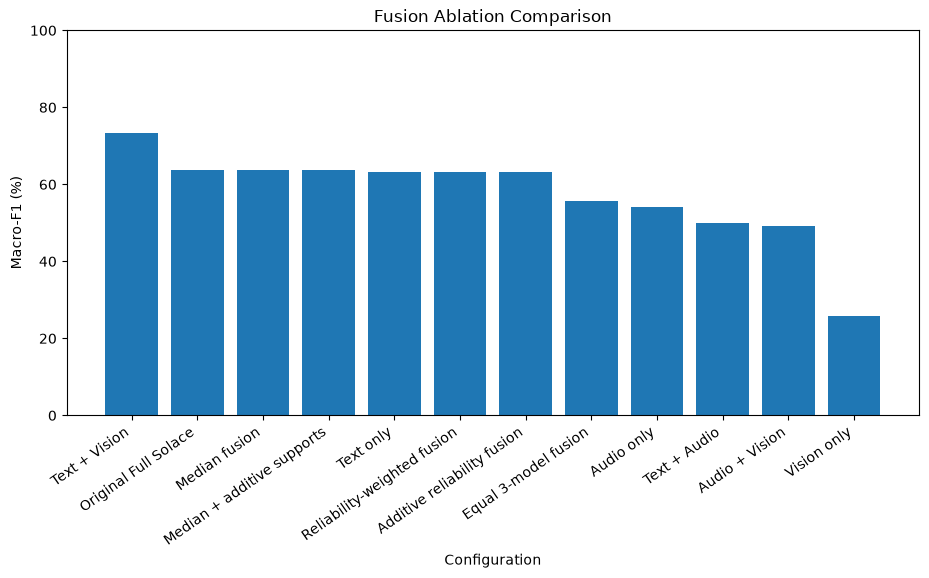

In [131]:
# bar chart for fusion ablation comparison
plt.figure(figsize=(11, 5))
plt.bar(ablation_display_df["Configuration"],ablation_display_df["Macro-F1 (%)"])
plt.ylabel("Macro-F1 (%)")
plt.xlabel("Configuration")
plt.title("Fusion Ablation Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=35,ha="right")
plt.show()

By compiling all of the information into a single comparison, the final design decision may be viewed in its entirety rather than being debated based on a single figure. It validates that a smaller pair can score higher on this set and that the three-model fusion is a reliable middle-of-the-pack option. The conclusion resolves this conflict in favor of robustness. The final section uses data that has not yet been seen to test the selected design.

## 24 Supporting Signal Weight Evaluation

This test compares different supporting signal weights using the development clips to examine their effect on fusion accuracy and macro-F1

In [132]:
# compute primary median
primary_median = (results_df[["Text strain", "Audio strain", "Vision strain"]] / 100).median(axis=1)

In [133]:
# compute support sum
support_sum = (results_df["Blink signal"] + results_df["Head signal"] + results_df["Speech signal"] + results_df["Disfluency signal"] + results_df["Lexical signal"]) / 100

In [134]:
# read Expected
expected = results_df["Expected"]

In [135]:
# define  evaluation support signals
def evaluate_support_weight(per_signal_weight):
    # total supports
    total_support = 5 * per_signal_weight
    # primary weights
    primary_weight = 1.0 - total_support
    # strains
    strain = np.clip(primary_median * primary_weight + support_sum * per_signal_weight,0, 1)
    # wellbeing
    wellbeing = 100 - strain * 100
    # predictions
    predicted = wellbeing.apply(wellbeing_band)
    # return the results dictionary
    return {
        "Per-signal %": per_signal_weight * 100,
        "Total support %": total_support * 100,
        "Accuracy": round(accuracy_score(expected, predicted), 3),
        "Macro-F1": round(f1_score(expected, predicted, average="macro"), 3)
    }

In [136]:
# build dataframe
sweep = pd.DataFrame([evaluate_support_weight(w) for w in [0.00, 0.004, 0.01, 0.02, 0.03, 0.04]])
sweep

,Per-signal %,Total support %,Accuracy,Macro-F1
0,0.0,0.0,0.667,0.637
1,0.4,2.0,0.667,0.637
2,1.0,5.0,0.600,0.533
3,2.0,10.0,0.667,0.615
4,3.0,15.0,0.667,0.615
5,4.0,20.0,0.667,0.615


**Analysis:**

Both 0% and 0.4% per signal obtain accuracy of 66.7% and macro-F1 of 0.637 on the development clips, according to the supporting signal weight evaluation. Lower macro-F1 scores are the result of higher weights. In order to allow a minor supporting contribution while maintaining the dominance of the primary models, Solace keeps 0.4% per signal, or 2% overall. However, these results do not demonstrate a classification improvement over using no supporting contribution.

## 25 Held-Out Evaluation

In order to determine how much the signals should contribute, this step sweeps the supporting-signal weight and assesses the complete fusion on a different held-out set of clips that were not involved in the above design decisions. The honest last check on a design that was refined on the development clips is called a held-out test.

In [137]:
# holdout folder
HOLDOUT_FOLDER = (PROJECT_ROOT / "data" / "raw" / "fusion_holdout")

In [138]:
# csv clips
holdout_manifest = pd.read_csv(HOLDOUT_FOLDER / "labels.csv")
holdout_manifest.head()

,Clip,Expected
0,fusion_holdout01,Low
1,fusion_holdout02,Low
2,fusion_holdout03,Low
3,fusion_holdout04,Low
4,fusion_holdout05,Mixed


In [139]:
# define holdout rows list
holdout_rows = []

In [140]:
for _, row in holdout_manifest.iterrows():
    # clip path
    clip_path = (HOLDOUT_FOLDER / f"{row['Clip']}.mp4")
    # temporary audio
    temporary_audio = None
    try:
        # set temporary_audio
        temporary_audio = (pipeline.extract_audio(str(clip_path)))
        # transcript
        transcript = pipeline.transcribe(temporary_audio,"English")
        # text score, audio score, video score and visual signals
        text_strain = pipeline.text_score(transcript)
        audio_strain = pipeline.audio_score(temporary_audio)
        vision_strain = pipeline.vision_score(str(clip_path))
        visual = pipeline.visual_signals(str(clip_path))
        # speech signals
        speech = pipeline.speech_signals(transcript,temporary_audio,"English")
        # define primary scores list
        primary_scores = [text_strain,audio_strain,vision_strain]
        # define supporting scores list
        supporting_scores = [speech["speech_signal"],speech["disfluency_signal"],speech["lexical_signal"],visual["blink_signal"],visual["head_signal"]]
        (primary_strain,supporting_strain,full_strain,primary_weight,) = pipeline.fuse(primary_scores,supporting_scores)
        full_wellbeing = 100 - (full_strain * 100)
        # predictions
        prediction = wellbeing_band(full_wellbeing)
        # holdout rows append to list
        holdout_rows.append({
            "Clip": row["Clip"],
            "Expected": row["Expected"],
            "Text wellbeing": 100 - text_strain * 100,
            "Audio wellbeing": 100 - audio_strain * 100,
            "Vision wellbeing": 100 - vision_strain * 100,
            "Primary wellbeing": 100 - primary_strain * 100,
            "Primary weight": primary_weight * 100,
            "Full Solace wellbeing": full_wellbeing,
            "Prediction": prediction
        })
    finally:
        if temporary_audio:
            Path(temporary_audio).unlink(missing_ok=True)

In [141]:
# holdout dataframe
holdout_df = pd.DataFrame(holdout_rows)

In [142]:
# compute accuracy
holdout_accuracy = accuracy_score(holdout_df["Expected"],holdout_df["Prediction"])
# compute macro-F1
holdout_macro_f1 = f1_score(holdout_df["Expected"],holdout_df["Prediction"],labels=["Low","Mixed","High"],average="macro",zero_division=0)

In [143]:
# print statements
print("Held-out fusion accuracy:",round(holdout_accuracy, 3))
# print "Held-out fusion Macro-F1"
print("Held-out fusion Macro-F1:",round(holdout_macro_f1, 3))

Held-out fusion accuracy: 0.583
Held-out fusion Macro-F1: 0.508


**Analysis:** 

The entire fusion scores 0.583 accuracy and 0.508 macro-F1 on a different held-out batch of twelve clips, which is lower than on the development clips. This is an honest and expected result of testing on unseen data, and it serves as a reminder that the development statistics are optimistic on such tiny samples. The subsequent support-weight sweep demonstrates that a light supporting weight (about 0.4% each signal, 2% overall) matches the best outcome and that bigger supporting weights are ineffective, reflecting the deployed system's real use of a small weight.

In [144]:
# show holdout dataframe
holdout_df

,Clip,Expected,Text wellbeing,Audio wellbeing,Vision wellbeing,Primary wellbeing,Primary weight,Full Solace wellbeing,Prediction
0,fusion_holdout01,Low,5.754687,5.536954,59.250887,5.754687,98.0,7.558715,Low
1,fusion_holdout02,Low,8.256051,21.834581,60.336242,21.834581,98.0,23.169579,Low
2,fusion_holdout03,Low,4.249774,53.990959,59.032055,53.990959,98.0,54.862563,Mixed
3,fusion_holdout04,Low,11.462250,11.442415,57.287814,11.462250,98.0,13.033951,Low
4,fusion_holdout05,Mixed,95.776270,80.270682,49.933652,80.270682,98.0,80.463453,High
5,fusion_holdout06,Mixed,94.976287,87.119839,53.696060,87.119839,98.0,86.977442,High
6,fusion_holdout07,Mixed,71.063729,90.387795,57.095964,71.063729,98.0,71.642454,High
7,fusion_holdout08,Mixed,92.514476,84.317878,57.153194,84.317878,98.0,84.423026,High
8,fusion_holdout09,High,99.432407,91.943242,70.040762,91.943242,98.0,91.704377,High
9,fusion_holdout10,High,99.607108,91.073370,63.315968,91.073370,98.0,91.193718,High


The study's conclusions from in-sample observations are transformed into a convincing approximation of actual behavior by testing on unseen clips, and the lower held-out scores are clearly stated as the true cost of the small samples involved. The weight sweep verifies that the application's choice of light supporting weight is appropriate. The entire ablation is brought together at the conclusion.

## 26 Conclusion

Instead of relying on a single headline figure, this notebook uses a methodical ablation to explain how Solace combines its modalities. The full Solace fusion, which consists of a median-based primary combination weighted at 98% and the five supporting signals at 0.4% each, achieves macro-F1 0.637 and accuracy 66.7% on the fifteen controlled clips, matching or surpassing every modality and surpassing naive equal averaging (0.556), which is pulled down by the weak vision channel.

Several honest caveats shape the conclusion. The Text+Vision pair actually scores higher (0.733), indicating that audio can be detrimental on these specific clips the Mixed and conflicting-modality cases defeat every configuration and the fusion drops to 0.508 macro-F1 on the held-out set. The fusion's margin over text-only is narrow (0.006 macro-F1) on this small set. When taken as a whole, these indicate that the development statistics are encouraging and that the most obvious subject for further research is conflicting-modality resolution.

The application's design, median-based primary fusion with a light supporting weight, is nevertheless well supported: median fusion ties the optimal strategy while being straightforward and robust to a single bad channel the supporting weights were confirmed to fire correctly and to help most at the small setting actually used and maintaining all three primary modalities trades a little peak accuracy on fifteen clips for resilience across the conditions a real deployment will meet. This open, evidence-based explanation of the fusion decision is the real contribution.

## References

[1] Y. Wu, Q. Mi, and T. Gao, "A Comprehensive Review of Multimodal Emotion Recognition: Techniques, Challenges, and Future Directions," Biomimetics, vol. 10, no. 7, Art. no. 418, 2025, doi: 10.3390/biomimetics10070418.